# 8. Reproducing Table I on RWC-R

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hale-T2/CHORD/blob/main/notebooks/08_evaluation_rwc_r.ipynb)

> **Paper ↔ code.** Section IV-A: both decoders on the 15 RWC-R tracks, chord labels reduced to major/minor triads, frame-wise P/R/F1 (Eqs. 19–20), Table I. Functions: `evaluate.reduce_label`, `evaluate.evaluate_track`, `evaluate.results_table`; the paper's numbers are in `chordlab.paper_results.TABLE_I`.

**Needs the RWC-R audio** (≈ 320 MB, downloaded automatically if missing — see notebook 1) and the derived chord labels from notebook 7, which ship with the repository.

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "Hale-T2/CHORD"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from C:\Users\uture\Downloads\files\chord-recognition-book\chord-recognition-book
data folder: D:\rwc-data


In [2]:
# Optional (Colab only): keep downloads on Google Drive so they survive the session.
# from google.colab import drive
# drive.mount("/content/drive")
# data.set_data_root("/content/drive/MyDrive/chordlab-data")

## 8.1 Reducing labels to 24 triads

The paper maps every annotated chord to its "fundamental" triad: dominant and major sevenths to the major triad, minor sevenths to the minor triad, and diminished, augmented and `N` to *no chord*. `evaluate.reduce_label` implements this (`method="quality"`), and also a stricter variant that looks at the actual pitch-class content (`method="bitmap"`: a power chord `E:maj(*3)` has no third, so it becomes `N`). Here is how every quality that occurs in RWC-P is treated — the RWC-R labels we derived are already plain triads.

In [3]:
ann = data.ensure_annotations()
all_labels = [l for pid in data.track_ids("P", ann) for l in data.load_chords(pid, ann)[1]]
print(len(all_labels), "chord segments in RWC-P,", len(set(all_labels)), "distinct labels")
evaluate.quality_mapping_table(all_labels).head(20)

13467 chord segments in RWC-P, 445 distinct labels


,count,example,reduced (quality),reduced (bitmap)
maj,6180,C:maj,C:maj,C:maj
min7,2004,C:min7,C:min,C:min
min,1953,C:min,C:min,C:min
7,907,C:7,C:maj,C:maj
maj7,827,C:maj7,C:maj,C:maj
sus4,372,C:sus4,N,N
maj6,359,C:maj6,C:maj,C:maj
N,263,N,N,N
dim,144,C:dim,N,N
sus2,100,C:sus2,N,N


## 8.2 Run both decoders on all 15 tracks

For each track: load audio (mono, 22 050 Hz) → CQT chroma → template decode and HMM decode with the paper's settings → paper metric against the MIDI-derived labels. We also record the standard `mir_eval` *majmin* score, which differs in one respect: reference frames outside the major/minor vocabulary (`N`) are *excluded* rather than counted as false positives.

In [4]:
from chordlab import paper_results

audio_root = data.ensure_rwc("R")
derived = root / "derived_annotations" / "chords_from_midi"
meta = data.load_metadata(ann)
hop_s = features.HOP_LENGTH / features.SR

results, predictions = {}, {}
for rid in data.track_ids("R", ann):
    y, sr = features.load_audio(data.audio_path(rid))
    chroma, times = features.cqt_chroma(y, sr)
    ref_iv, ref_lab = data.load_chords(rid, derived_dir=derived)
    st_t, _ = templates.template_decode(chroma)
    st_h, _ = hmm.hmm_decode(chroma, p_self=0.90, temperature=1.0)
    results[rid] = {"CQT-Template": evaluate.evaluate_track(st_t, times, ref_iv, ref_lab, hop_s),
                    "CQT-HMM (Viterbi)": evaluate.evaluate_track(st_h, times, ref_iv, ref_lab, hop_s)}
    predictions[rid] = (times, st_t, st_h, ref_iv, ref_lab)
    print(f"{rid} {meta.loc[rid, 'Title'][:30]:30s} template F1 {results[rid]['CQT-Template']['F1']:.3f}   HMM F1 {results[rid]['CQT-HMM (Viterbi)']['F1']:.3f}")

RWC_R001 Chou chou                      template F1 0.434   HMM F1 0.000


RWC_R002 Musunde hiraite                template F1 0.528   HMM F1 0.770


RWC_R003 Akai kutsu                     template F1 0.561   HMM F1 0.457


RWC_R004 Nanatsu no ko                  template F1 0.456   HMM F1 0.451


RWC_R005 Momotaro                       template F1 0.359   HMM F1 0.412


...

RWC_R011 John Brown Had A Little Indian template F1 0.518   HMM F1 0.486


RWC_R012 When the Saints Go Marching in template F1 0.295   HMM F1 0.592


RWC_R013 Silent Night                   template F1 0.670   HMM F1 0.486


RWC_R014 Turkey In The Straw            template F1 0.337   HMM F1 0.687


RWC_R015 My Bonny                       template F1 0.707   HMM F1 0.576


In [5]:
table_i = evaluate.results_table(results)
(root / "results").mkdir(exist_ok=True)
table_i.to_csv(root / "results" / "table_I_rwc_r.csv")
table_i.round(4)

CQT-Template                 CQT-HMM (Viterbi)                
                    P       R      F1                 P       R      F1
RWC_R001       0.4318  0.4369  0.4343            0.0000  0.0000  0.0000
RWC_R002       0.5199  0.5367  0.5282            0.7578  0.7822  0.7698
RWC_R003       0.5560  0.5661  0.5610            0.4530  0.4612  0.4571
RWC_R004       0.4479  0.4646  0.4561            0.4427  0.4593  0.4508
RWC_R005       0.3517  0.3671  0.3592            0.4038  0.4215  0.4124
RWC_R006       0.2612  0.2773  0.2690            0.5325  0.5654  0.5485
RWC_R007       0.5507  0.5692  0.5598            0.6483  0.6701  0.6590
RWC_R008       0.2455  0.2620  0.2535            0.3421  0.3650  0.3532
RWC_R009       0.6277  0.6374  0.6325            0.5079  0.5158  0.5118
RWC_R010       0.3755  0.4033  0.3889            0.6645  0.7138  0.6883
RWC_R011       0.5116  0.5241  0.5177            0.4805  0.4922  0.4863
RWC_R012       0.2915  0.2983  0.2949            0.5853  0.5989  0.5921
RWC_R013       0.6653  0.6756  0.6704            0.4821  0.4895  0.4857
RWC_R014       0.3313  0.3438  0.3374            0.6747  0.7002  0.6872
RWC_R015       0.6958  0.7184  0.7069            0.5673  0.5857  0.5764
Average        0.4576  0.4720  0.4647            0.5028  0.5214  0.5119

## 8.3 Side by side with the paper

The paper reports an average F1 of 0.5758 (template) and 0.6771 (HMM), a gain of 0.1013 absolute. Our ground truth is a reconstruction (notebook 7), so expect the decimals to differ; the questions to ask are: *does the HMM gain survive*, *is it the same size*, and *is the ranking of tracks similar*?

In [6]:
ours = table_i.xs("F1", axis=1, level=1)
paper = paper_results.TABLE_I.xs("F1", axis=1, level=1)
compare = pd.concat({"ours": ours, "paper": paper}, axis=1)
compare["HMM gain (ours)"] = ours["CQT-HMM (Viterbi)"] - ours["CQT-Template"]
compare["HMM gain (paper)"] = paper["CQT-HMM (Viterbi)"] - paper["CQT-Template"]
compare.round(4)

ours                          paper                    \
         CQT-Template CQT-HMM (Viterbi) CQT-Template CQT-HMM (Viterbi)   
RWC_R001       0.4343            0.0000       0.5414            0.5915   
RWC_R002       0.5282            0.7698       0.6002            0.7022   
RWC_R003       0.5610            0.4571       0.6133            0.7273   
RWC_R004       0.4561            0.4508       0.5325            0.6287   
RWC_R005       0.3592            0.4124       0.4555            0.4961   
RWC_R006       0.2690            0.5485       0.3762            0.3959   
RWC_R007       0.5598            0.6590       0.6255            0.7892   
RWC_R008       0.2535            0.3532       0.3427            0.4618   
RWC_R009       0.6325            0.5118       0.7622            0.7974   
RWC_R010       0.3889            0.6883       0.5380            0.6632   
RWC_R011       0.5177            0.4863       0.6393            0.7851   
RWC_R012       0.2949            0.5921       0.4996            0.6371   
RWC_R013       0.6704            0.4857       0.8046            0.9037   
RWC_R014       0.3374            0.6872       0.5370            0.7681   
RWC_R015       0.7069            0.5764       0.7684            0.8094   
Average        0.4647            0.5119       0.5758            0.6771   

         HMM gain (ours) HMM gain (paper)  
                                           
RWC_R001         -0.4343           0.0501  
RWC_R002          0.2416           0.1020  
RWC_R003         -0.1039           0.1140  
RWC_R004         -0.0052           0.0962  
RWC_R005          0.0532           0.0406  
RWC_R006          0.2795           0.0197  
RWC_R007          0.0992           0.1637  
RWC_R008          0.0997           0.1191  
RWC_R009         -0.1207           0.0352  
RWC_R010          0.2994           0.1252  
RWC_R011         -0.0314           0.1458  
RWC_R012          0.2972           0.1375  
RWC_R013         -0.1847           0.0991  
RWC_R014          0.3498           0.2311  
RWC_R015         -0.1306           0.0410  
Average           0.0472           0.1014

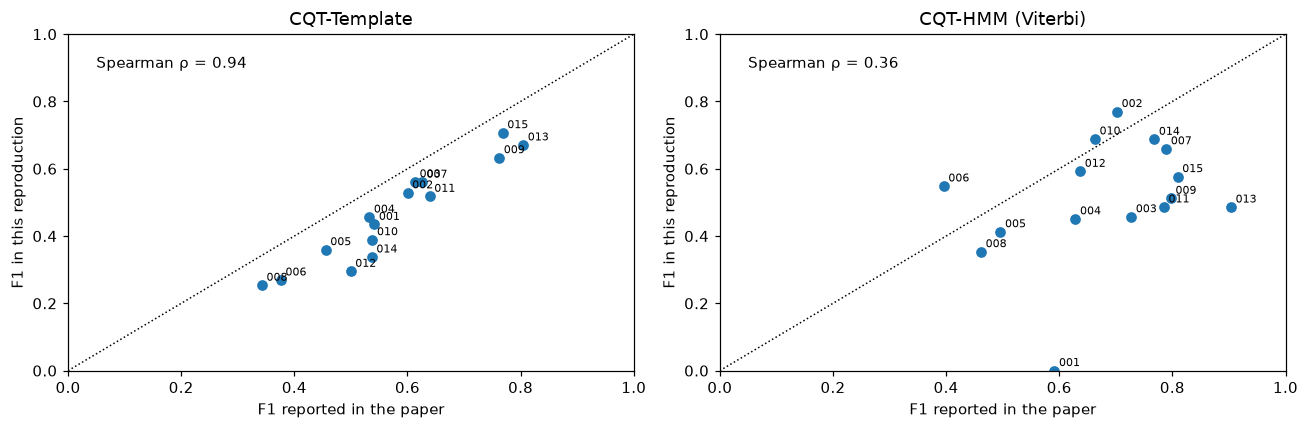

In [7]:
from scipy.stats import spearmanr

tracks = [t for t in ours.index if t != "Average"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model in zip(axes, ours.columns):
    ax.scatter(paper.loc[tracks, model], ours.loc[tracks, model])
    for t in tracks:
        ax.annotate(t[-3:], (paper.loc[t, model], ours.loc[t, model]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.plot([0, 1], [0, 1], "k:", lw=1); ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="F1 reported in the paper", ylabel="F1 in this reproduction", title=model)
    rho = spearmanr(paper.loc[tracks, model], ours.loc[tracks, model]).correlation
    ax.text(0.05, 0.9, f"Spearman ρ = {rho:.2f}", transform=ax.transAxes)
plt.tight_layout(); plt.show()

## 8.4 Where does the HMM gain come from?

The paper's reading: the HMM removes isolated false positives, so precision rises more than recall. Check both claims, then look at a track.

average gain of the HMM over template matching:
 P     0.0453
R     0.0493
F1    0.0472
Name: Average, dtype: float64


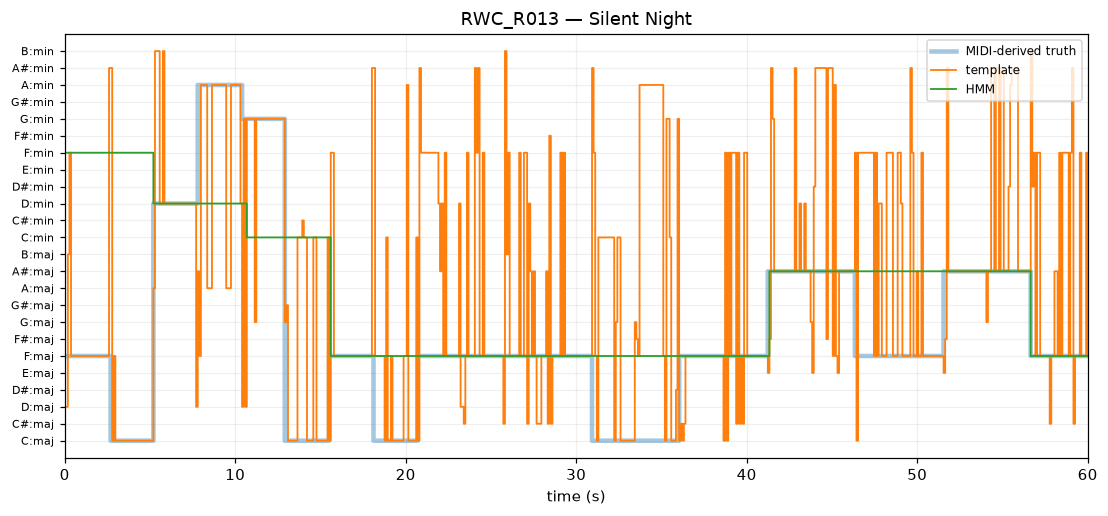

In [8]:
gain = table_i.loc["Average", "CQT-HMM (Viterbi)"] - table_i.loc["Average", "CQT-Template"]
print("average gain of the HMM over template matching:\n", gain.round(4))

rid = "RWC_R013"       # the paper's best track (Silent Night)
times, st_t, st_h, ref_iv, ref_lab = predictions[rid]
truth = evaluate.labels_to_frames(ref_iv, ref_lab, times)
fig, ax = plt.subplots(figsize=(12, 5))
plots.plot_states(times, truth, st_t, st_h, labels=["MIDI-derived truth", "template", "HMM"], ax=ax, title=f"{rid} — {meta.loc[rid, 'Title']}")
ax.set_xlim(0, 60); plt.show()

## 8.5 The `N` problem and mir_eval

Both decoders output a chord in *every* frame, including the silence before `audio_start` and after `audio_end`. With the paper's counting each such frame is a false positive, so precision can never reach 1 on a track with leading silence. `mir_eval` instead ignores reference `N` frames in its *majmin* score. Compare the two views:

In [9]:
me = pd.DataFrame({(model, k): {rid: results[rid][model][k] for rid in results} for model in results["RWC_R001"] for k in ("F1", "mir_eval_majmin")})
me.loc["Average"] = me.mean()
me.round(4)

CQT-Template                 CQT-HMM (Viterbi)                
                   F1 mir_eval_majmin                F1 mir_eval_majmin
RWC_R001       0.4343          0.4310            0.0000          0.0000
RWC_R002       0.5282          0.5327            0.7698          0.7755
RWC_R003       0.5610          0.5620            0.4571          0.4599
RWC_R004       0.4561          0.4476            0.4508          0.4485
RWC_R005       0.3592          0.3513            0.4124          0.4101
RWC_R006       0.2690          0.2626            0.5485          0.5401
RWC_R007       0.5598          0.5540            0.6590          0.6574
RWC_R008       0.2535          0.2449            0.3532          0.3455
RWC_R009       0.6325          0.6287            0.5118          0.5141
RWC_R010       0.3889          0.3779            0.6883          0.6714
RWC_R011       0.5177          0.5235            0.4863          0.4934
RWC_R012       0.2949          0.2967            0.5921          0.5964
RWC_R013       0.6704          0.6701            0.4857          0.4895
RWC_R014       0.3374          0.3375            0.6872          0.6913
RWC_R015       0.7069          0.7128            0.5764          0.5831
Average        0.4647          0.4622            0.5119          0.5117

## 8.6 Beyond the paper: three quick variations

Each of these is a single-line change. Run them and extend Table I with new columns.

In [10]:
def run_variant(name, decode):
    f1 = []
    for rid in data.track_ids("R", ann):
        times, st_t, st_h, ref_iv, ref_lab = predictions[rid]
        y, sr = features.load_audio(data.audio_path(rid))
        st = decode(y, sr)
        t = features.frame_times(len(st), sr)                      # STFT and CQT may differ by a frame
        f1.append(evaluate.evaluate_track(st, t, ref_iv, ref_lab, hop_s, with_mir_eval=False)["F1"])
    print(f"{name:45s} mean F1 = {np.mean(f1):.4f}")
    return f1

variants = {
    "HMM, sharper emissions (τ = 0.1)": lambda y, sr: hmm.hmm_decode(features.cqt_chroma(y, sr)[0], temperature=0.1)[0],
    "HMM, p = 0.99": lambda y, sr: hmm.hmm_decode(features.cqt_chroma(y, sr)[0], p_self=0.99)[0],
    "template on the harmonic part (HPSS)": lambda y, sr: templates.template_decode(features.cqt_chroma(features.harmonic_part(y), sr)[0])[0],
    "template on STFT chroma": lambda y, sr: templates.template_decode(features.stft_chroma(y, sr)[0])[0],
}
variant_f1 = {name: run_variant(name, fn) for name, fn in variants.items()}

HMM, sharper emissions (τ = 0.1)              mean F1 = 0.7316


HMM, p = 0.99                                 mean F1 = 0.5022


template on the harmonic part (HPSS)          mean F1 = 0.4929


template on STFT chroma                       mean F1 = 0.4862


## Exercises

1. Plot HMM gain per track against the mean chord duration from notebook 7's summary table. Is the gain larger for slow songs, as the lag argument of notebook 6 predicts?
2. Evaluate only between `audio_start` and `audio_end` (from `metadata.csv`). How much of the precision gap was silence?
3. Replace the derived labels by ones computed with `grid="bar"` and re-run. How many decimals of Table I move? This is your personal estimate of the ground-truth uncertainty.
4. The paper's Table I lists precision **above** recall for no track. Explain why, with the paper's TP/FP/FN definitions and a decoder that never outputs `N`, precision can never exceed recall.